# Modelling, Dataset 1: ULB Credit Card Fraud

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = '../Dataset/processed/creditcard_clean.csv'
OUT_DIR = 'outputs/creditcard'
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=['Class'])
y = df['Class']
print("X shape:", X.shape)
print("Fraud rate:", y.mean())

X shape: (280922, 30)
Fraud rate: 0.0016837413944084123


## Model setup

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])

# max_depth/min_samples_leaf capped so RF doesn't just memorise individual rare fraud rows
rf_clf = RandomForestClassifier(
    class_weight='balanced', n_estimators=200, max_depth=18, min_samples_leaf=8,
    random_state=RANDOM_STATE, n_jobs=-1
)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'auprc': 'average_precision',
}

## Cross-validated metrics

In [4]:
lr_cv = cross_validate(lr_pipe, X, y, cv=cv, scoring=scoring)
rf_cv = cross_validate(rf_clf, X, y, cv=cv, scoring=scoring)

rows = []
for name, res in [('Logistic Regression', lr_cv), ('Random Forest', rf_cv)]:
    for metric in scoring:
        scores = res[f'test_{metric}']
        rows.append({'model': name, 'metric': metric, 'mean': scores.mean(), 'std': scores.std()})

metrics_df = pd.DataFrame(rows)
metrics_df

,model,metric,mean,std
0,Logistic Regression,precision,0.058223,0.001425
1,Logistic Regression,recall,0.902755,0.034841
2,Logistic Regression,f1,0.109366,0.002269
3,Logistic Regression,auprc,0.732771,0.045481
4,Random Forest,precision,0.849965,0.015721
5,Random Forest,recall,0.805487,0.041953
6,Random Forest,f1,0.826873,0.029392
7,Random Forest,auprc,0.827340,0.032465


In [5]:
metrics_df.to_csv(f'{OUT_DIR}/model_metrics.csv', index=False)
print("Saved to", f'{OUT_DIR}/model_metrics.csv')

Saved to outputs/creditcard/model_metrics.csv


## Confusion matrices (out-of-fold predictions, 0.5 threshold)

Raw counts, not just precision/recall, since the fraud class is thin enough (473 cases) that
percentages alone hide how few actual cases are involved.

Logistic Regression confusion matrix (rows=actual, cols=predicted):
[[273531   6918]
 [    46    427]]

Random Forest confusion matrix (rows=actual, cols=predicted):
[[280382     67]
 [    92    381]]


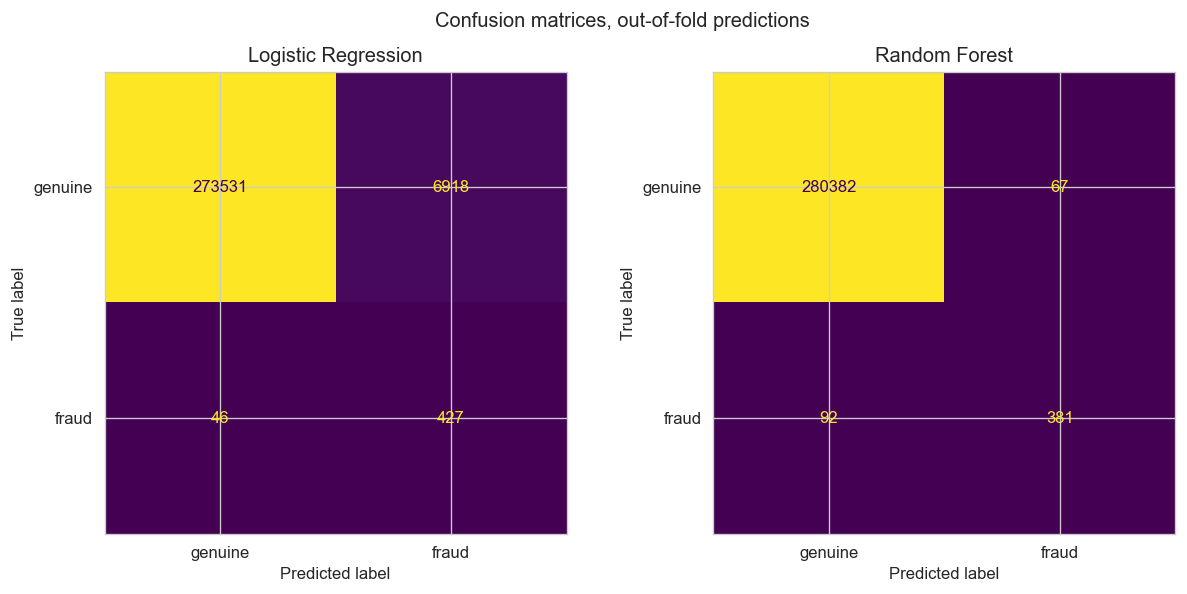

In [6]:
lr_pred_oof = cross_val_predict(lr_pipe, X, y, cv=cv, method='predict')
rf_pred_oof = cross_val_predict(rf_clf, X, y, cv=cv, method='predict')

lr_cm = confusion_matrix(y, lr_pred_oof)
rf_cm = confusion_matrix(y, rf_pred_oof)

print("Logistic Regression confusion matrix (rows=actual, cols=predicted):")
print(lr_cm)
print("\nRandom Forest confusion matrix (rows=actual, cols=predicted):")
print(rf_cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(lr_cm, display_labels=['genuine', 'fraud']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(rf_cm, display_labels=['genuine', 'fraud']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')
fig.suptitle('Confusion matrices, out-of-fold predictions')
fig.savefig(f'{OUT_DIR}/confusion_matrix.png', bbox_inches='tight')

## Precision-recall curves (out-of-fold predictions)

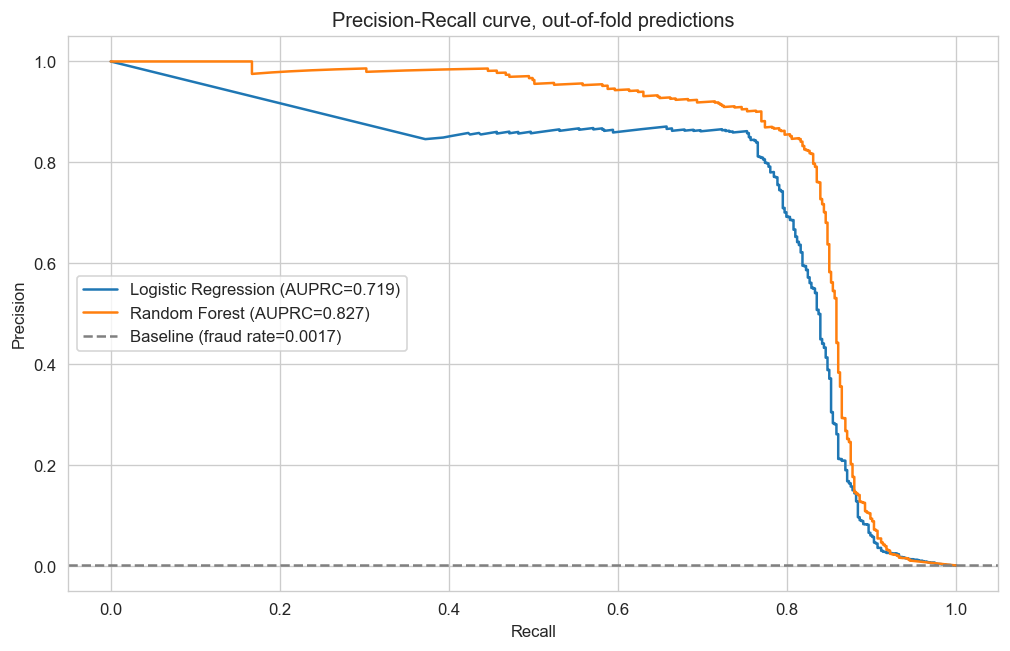

In [7]:
# cross_val_predict gives leak-free out-of-fold probabilities for the whole dataset, one PR
# curve instead of 5 noisy small ones
lr_proba = cross_val_predict(lr_pipe, X, y, cv=cv, method='predict_proba')[:, 1]
rf_proba = cross_val_predict(rf_clf, X, y, cv=cv, method='predict_proba')[:, 1]

lr_precision, lr_recall, _ = precision_recall_curve(y, lr_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y, rf_proba)
lr_auprc = average_precision_score(y, lr_proba)
rf_auprc = average_precision_score(y, rf_proba)

fig, ax = plt.subplots()
ax.plot(lr_recall, lr_precision, label=f'Logistic Regression (AUPRC={lr_auprc:.3f})')
ax.plot(rf_recall, rf_precision, label=f'Random Forest (AUPRC={rf_auprc:.3f})')
ax.axhline(y.mean(), color='grey', linestyle='--', label=f'Baseline (fraud rate={y.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve, out-of-fold predictions')
ax.legend()
fig.savefig(f'{OUT_DIR}/pr_curve.png', bbox_inches='tight')

## Business-framed threshold: precision at 90% recall

A single 0.5-threshold number isn't the whole story for a fraud team, they can pick the
operating point. This pulls out what precision costs to catch 90% of fraud, a concrete number
for the metric justification and the Part 2 video.

In [8]:
def precision_at_recall(precision, recall, target_recall=0.90):
    # recall is monotonically decreasing along the curve, take the highest-precision point that
    # still clears the target
    idx = np.where(recall >= target_recall)[0]
    if len(idx) == 0:
        return None
    best = idx[np.argmax(precision[idx])]
    return precision[best]

target_recall = 0.90
threshold_rows = []
for name, prec, rec in [('Logistic Regression', lr_precision, lr_recall), ('Random Forest', rf_precision, rf_recall)]:
    p = precision_at_recall(prec, rec, target_recall)
    threshold_rows.append({'model': name, 'recall_target': target_recall, 'precision_at_target': p})
    print(f"{name}: at {target_recall:.0%} recall, precision is {p:.3f} "
          f"(only {p*100:.1f} out of every 100 flagged transactions would actually be fraud)")

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(f'{OUT_DIR}/threshold_summary.csv', index=False)
print("\nSaved to", f'{OUT_DIR}/threshold_summary.csv')

Logistic Regression: at 90% recall, precision is 0.061 (only 6.1 out of every 100 flagged transactions would actually be fraud)
Random Forest: at 90% recall, precision is 0.094 (only 9.4 out of every 100 flagged transactions would actually be fraud)

Saved to outputs/creditcard/threshold_summary.csv


## Feature importance / coefficients (fit on full data)

In [9]:
# fit on the whole dataset here, this is for interpretability only, reported metrics above come
# from CV, not this fit
lr_pipe.fit(X, y)
rf_clf.fit(X, y)

rf_importance = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
lr_coef = pd.Series(lr_pipe.named_steps['clf'].coef_[0], index=X.columns)
lr_coef_sorted = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index)

print("Top 10 RF features:")
print(rf_importance.head(10))
print("\nTop 10 LR coefficients (by magnitude):")
print(lr_coef_sorted.head(10))

Top 10 RF features:
V14    0.184584
V10    0.127305
V4     0.121294
V17    0.100485
V12    0.079224
V11    0.071810
V3     0.052795
V7     0.035039
V16    0.030061
V2     0.019938
dtype: float64

Top 10 LR coefficients (by magnitude):
Amount    2.341593
V1        1.341458
V14      -1.321743
V12      -1.229229
V4        1.119595
V2        1.113377
V5        1.069236
V10      -0.815014
V7       -0.802837
V6       -0.757927
dtype: float64


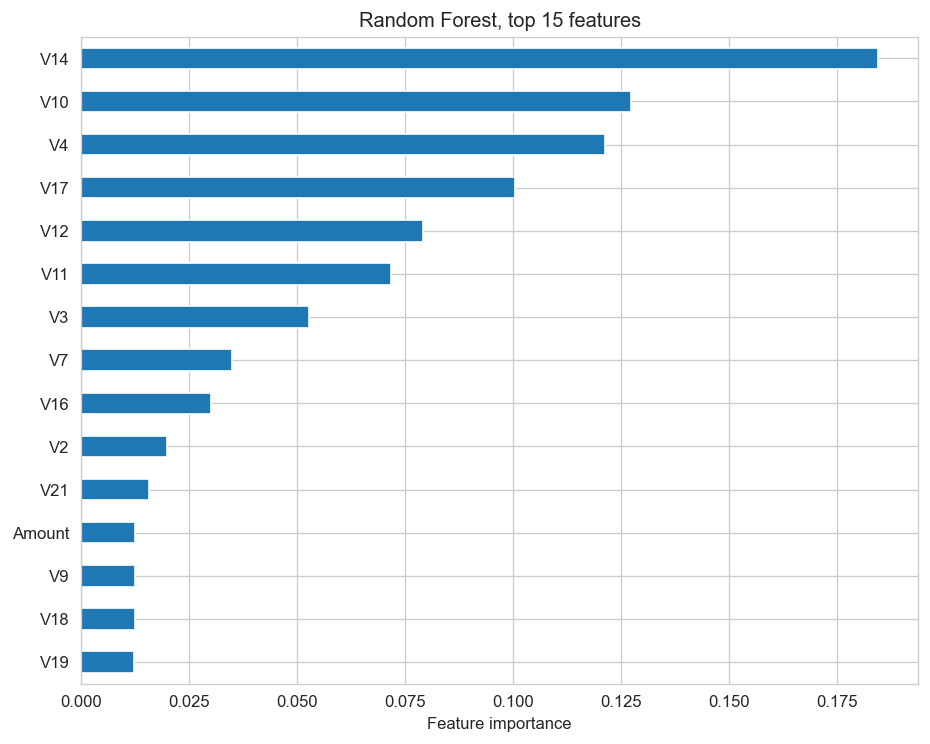

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
rf_importance.head(15)[::-1].plot(kind='barh', ax=ax)
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest, top 15 features')
fig.savefig(f'{OUT_DIR}/rf_feature_importance.png', bbox_inches='tight')

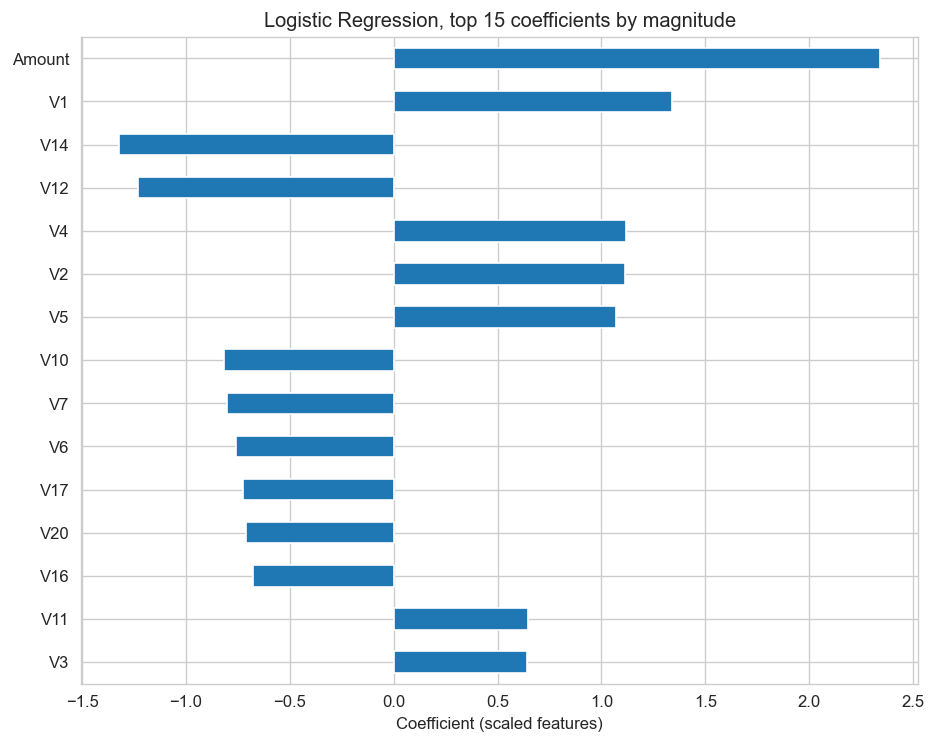

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
lr_coef_sorted.head(15)[::-1].plot(kind='barh', ax=ax)
ax.set_xlabel('Coefficient (scaled features)')
ax.set_title('Logistic Regression, top 15 coefficients by magnitude')
fig.savefig(f'{OUT_DIR}/lr_coefficients.png', bbox_inches='tight')

## Summary

In [12]:
print("--- Cross-validated metrics (mean +/- std) ---")
for name, res in [('Logistic Regression', lr_cv), ('Random Forest', rf_cv)]:
    print(f"{name}:")
    for metric in scoring:
        scores = res[f'test_{metric}']
        print(f"  {metric}: {scores.mean():.4f} +/- {scores.std():.4f}")

print("\nTop 5 RF features:", rf_importance.head(5).index.tolist())
print("Top 5 LR features (by |coef|):", lr_coef_sorted.head(5).index.tolist())

--- Cross-validated metrics (mean +/- std) ---
Logistic Regression:
  precision: 0.0582 +/- 0.0014
  recall: 0.9028 +/- 0.0348
  f1: 0.1094 +/- 0.0023
  auprc: 0.7328 +/- 0.0455
Random Forest:
  precision: 0.8500 +/- 0.0157
  recall: 0.8055 +/- 0.0420
  f1: 0.8269 +/- 0.0294
  auprc: 0.8273 +/- 0.0325

Top 5 RF features: ['V14', 'V10', 'V4', 'V17', 'V12']
Top 5 LR features (by |coef|): ['Amount', 'V1', 'V14', 'V12', 'V4']
